# Imbalance metric


In [1]:
import common
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
random.seed(123)
np.random.seed(123)

ncases = 100_000
ngroups = 22
n_replicate = 5

# cases = []
# for f in np.linspace(-10, 5, 1000):
#     while True:
#         case = np.rint([max(1, np.random.uniform(f, 5.05)) for _ in range(ngroups)])
#         if np.max(case) == 5:
#             break
#     cases.append(case)
cases = common.prepareCases(ncases, ngroups)
all_metrics = {
    'minimum': np.array(cases).min(axis=1),
}
pd.DataFrame(cases).shape

(100000, 22)

## Shannon entropy
$$
H = - \sum_{i=1}^{n_g} \frac{c_i}{n} \log \frac{c_i}{n}
$$

- $n_g$ number of groups
- $c_i$ count data points in group $i$
- $n$ total number of data points

Use `scipy.stats.entropy` implementation

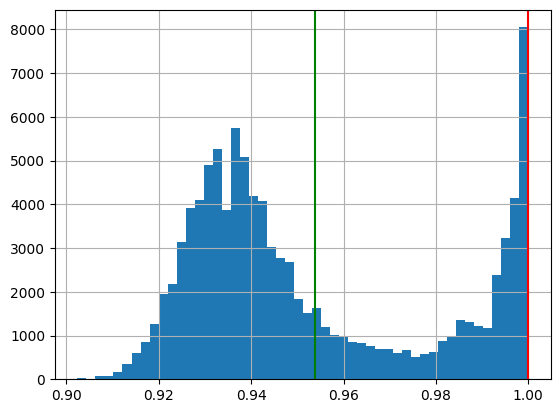

In [3]:
from metrics import entropy

metrics = pd.Series(entropy(case) for case in cases)
ax = metrics.hist(bins=50)
ax.axvline(entropy([5] * ngroups), color='red')
ax.axvline(entropy([5] + [1] * (ngroups - 1)), color='green')
all_metrics['entropy'] = metrics

## Relative difference
$$
𝑖𝑚𝑏𝑎𝑙𝑎𝑛𝑐𝑒 = \frac{\max(\mathrm{groups}) - \min(\mathrm{𝑠𝑎𝑚𝑝𝑙𝑒𝑠})}
                {\sum(\mathrm{groups}) - ngroups}
$$


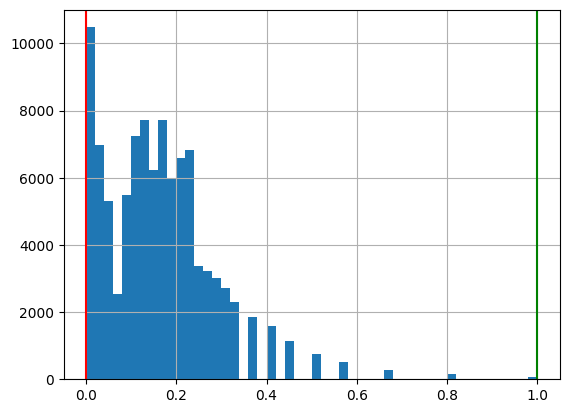

In [4]:
from metrics import relative_difference

metrics = pd.Series(relative_difference(case) for case in cases)
ax = metrics.hist(bins=50)
ax.axvline(relative_difference([5] * ngroups), color='red')
ax.axvline(relative_difference([5] + [1] * (ngroups - 1)), color='green')
all_metrics['relative_difference'] = metrics

## L1 distance
$$
distance = \sum_{\mathrm{groups}} |c_i - g|
$$


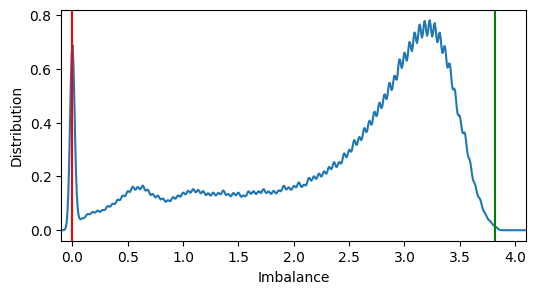

np.float64(3.8181818181818183)

In [5]:
from metrics import L1_distance

metrics = pd.Series(L1_distance(case) for case in cases)
# ax = metrics.hist(bins=30)
fig, ax = plt.subplots(figsize=(6, 3))
metrics.plot.density(bw_method=0.02, ax=ax)
ax.set_xlim(-0.1, 4.1)
ax.axvline(L1_distance([n_replicate] * ngroups), color='red')
ax.axvline(L1_distance([n_replicate] + [1] * (ngroups - 1)), color='green')
ax.set_xlabel('Imbalance')
ax.set_ylabel('Distribution')
all_metrics['L1_distance'] = metrics

plt.savefig(common.FIGURES_DIR / 'L1imbalance.png', format='png', bbox_inches='tight', dpi=300)
plt.show()
L1_distance([n_replicate] + [1] * (ngroups - 1))



In [6]:
# pd.Series([case for case in cases if L1_distance(case) > 2.5][0]).hist()


## Mean number of replica

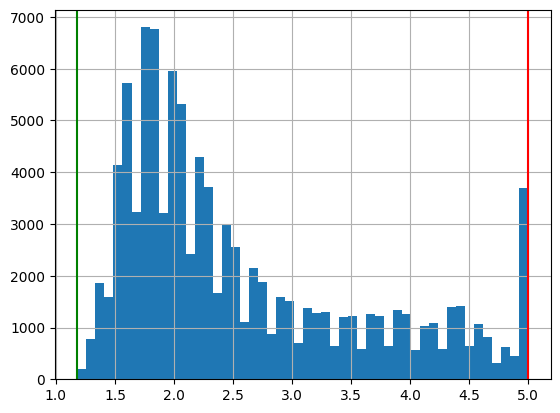

In [7]:

from metrics import mean_replica
metrics = pd.Series(mean_replica(case) for case in cases)
ax = metrics.hist(bins=50)
ax.axvline(mean_replica([5] * ngroups), color='red')
ax.axvline(mean_replica([5] + [1] * (ngroups - 1)), color='green')
all_metrics['mean_replica'] = metrics

## Imbalance degree

J. Ortigosa-Hernández, I. Inza, and J. A. Lozano, “Measuring the class-imbalance extent of multi-class problems,” Pattern Recognit. Lett., 2017. DOI: 10.1016/j.patrec.2017.08.002


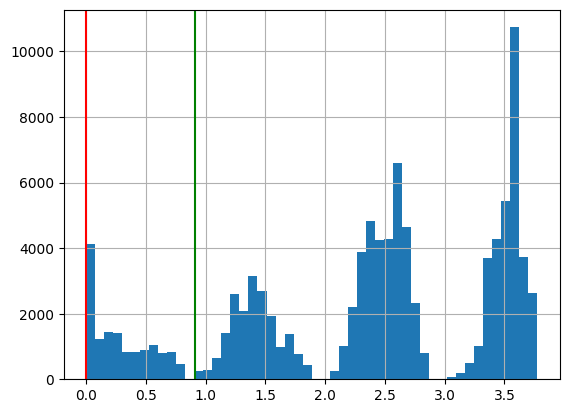

In [8]:
from metrics import imbalance_degree

metrics = pd.Series(imbalance_degree(case) for case in cases)
ax = metrics.hist(bins=50)
ax.axvline(imbalance_degree([5] * ngroups), color='red')
ax.axvline(imbalance_degree([5] + [1] * (ngroups - 1)), color='green')
all_metrics['imbalance_degree'] = metrics

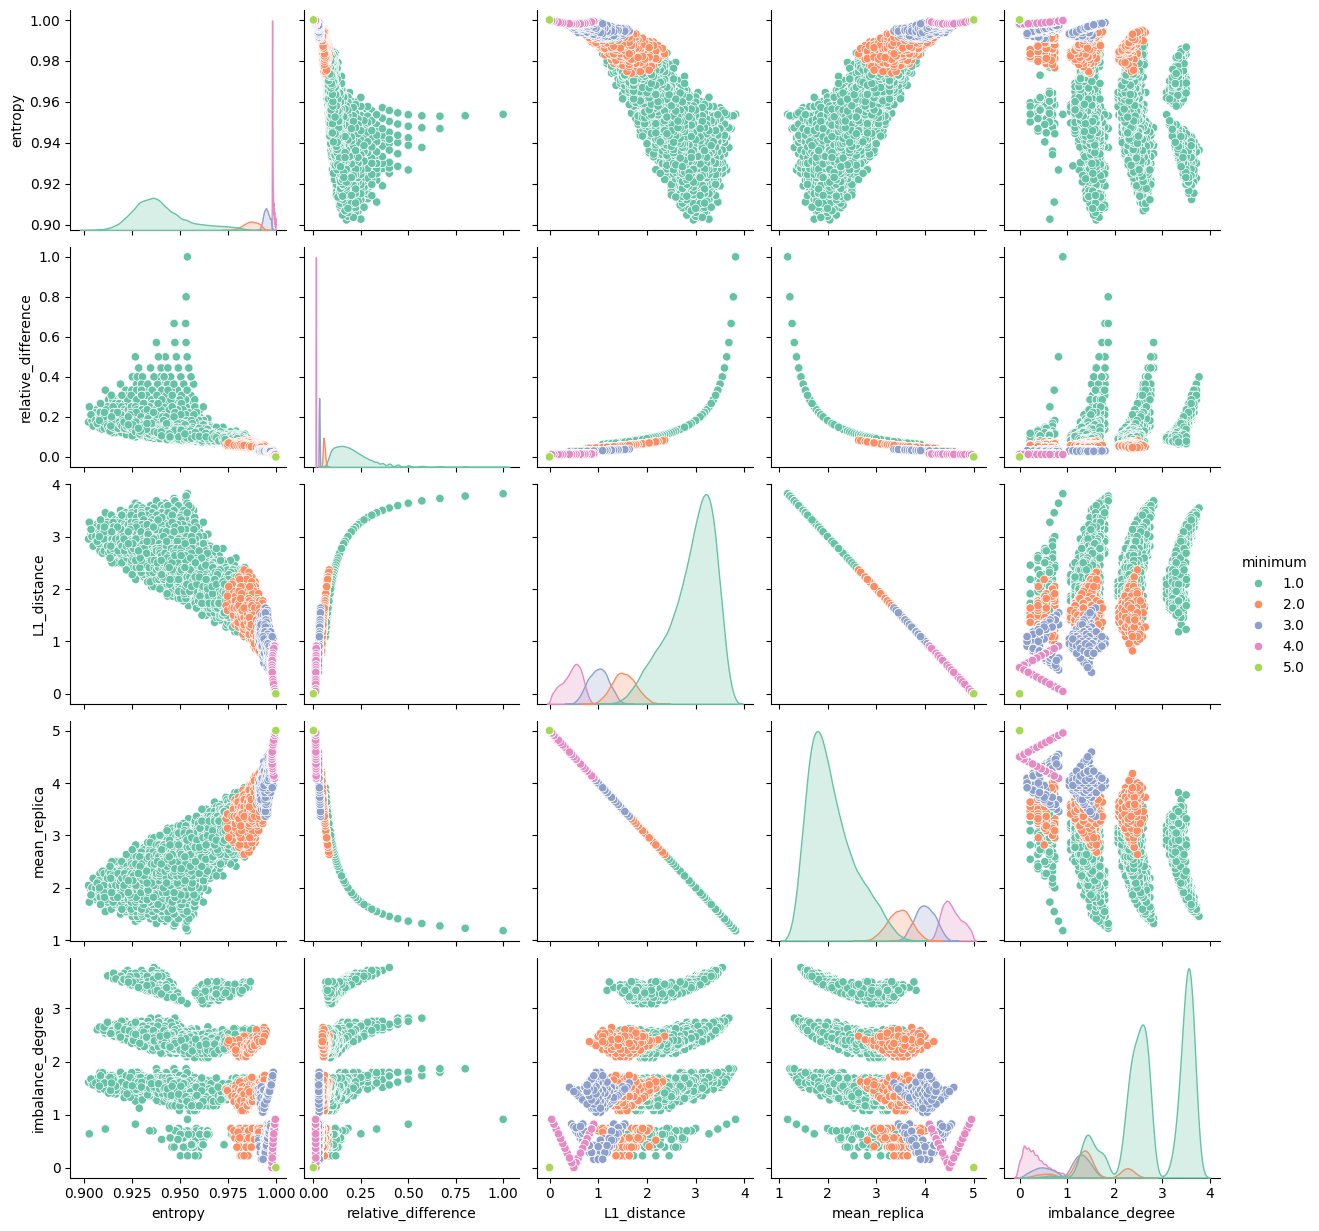

In [9]:
import seaborn as sns
df = pd.DataFrame(all_metrics)

sns.pairplot(df, palette='Set2', hue='minimum')